In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [60]:
US_PATH = "./data/comprehensive_foods_usda_V1.csv"
GL_PATH = "./data/foods_health_scores_allergens.csv"

df_us = pd.read_csv(US_PATH)
df_gl = pd.read_csv(GL_PATH)



In [61]:
df_us.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


In [62]:
df_gl.head()

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged


In [63]:
df_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  object 
 2   data_type          40000 non-null  object 
 3   food_category      39954 non-null  object 
 4   brand_owner        31383 non-null  object 
 5   brand_name         30254 non-null  object 
 6   ingredients        31656 non-null  object 
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  object 
 9   household_serving  30790 non-null  object 
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       229

In [64]:
df_gl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        4785 non-null   object 
 1   brands              4751 non-null   object 
 2   categories          4913 non-null   object 
 3   ingredients         4797 non-null   object 
 4   nutriscore_grade    4983 non-null   object 
 5   nova_group          4522 non-null   float64
 6   ecoscore_grade      4984 non-null   object 
 7   allergens           3332 non-null   object 
 8   energy_kcal         4682 non-null   float64
 9   fat_100g            4695 non-null   float64
 10  saturated_fat_100g  4617 non-null   float64
 11  carbs_100g          4676 non-null   float64
 12  sugars_100g         4631 non-null   float64
 13  fiber_100g          3495 non-null   float64
 14  proteins_100g       4690 non-null   float64
 15  salt_100g           4653 non-null   float64
 16  sodium

In [65]:
#Primero vamos a comparar de ambos sets, productos envasados o de marcas, para comparar lo mismo de ambas partes, ya que si no
#no sería una comparación justa ni equilibrada.
#Debemos de entender que aquellos productos que son branded, suelen ser productos envasados, con su marca, con su etiqueta y 
#más o menos procesados.

gl_pack = df_gl[df_gl["food_type"] == "Branded/Packaged"].copy()
us_pack = df_us[df_us["data_type"] == "Branded"].copy()

print("Global envasado:", gl_pack.shape)
print("US envasado:", us_pack.shape)

Global envasado: (4997, 24)
US envasado: (31842, 24)


In [66]:
#visualizamos las unidades de medida y medidas del df de US, ya que las globales están 
#estandarizadas a 100g

us_pack[["food_name","brand_name","brand_owner","serving_size","serving_unit"]].head(12)

,food_name,brand_name,brand_owner,serving_size,serving_unit
8158,AdvancePierre Flamebroiled Rib Shaped Pork Pa...,Advance Pierre,Tyson Foods Inc.,100.0,GRM
8159,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,GOLDEN PLATTER,Golden Platter Foods Inc.,85.0,GRM
8160,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,HERITAGE SELECT,SLT Foods Inc.,46.0,GRM
8161,ARTISANAL COLLECTION SPAGHETTI PASTA,BARILLA,Barilla G & R F.Lli S.P.A.,56.0,GRM
8162,AUTHENTIC BARREL RIPENED FETA CHEESE,APHRODITE,"Wdh, LLC",28.0,GRM
8163,BERRY NUT BLEND BREAKFAST IN THE GO!,EMERALD,"Snyder's-Lance, Inc.",42.5,g
8164,"BLACK CHERRY PURE ENERGY SELTZER, BLACK CHERRY",TRUE NORTH,Energy Beverages LLC,355.0,MLT
8165,BLUE LAKE CUT GREEN BEANS,DEL MONTE,Del Monte Foods Inc.,121.0,GRM
8166,BRIE TRIPLE CRME SOFT-RIPENED CHEESE,PRSIDENT,Besnier S.A.,28.0,GRM
8167,BUFFALO STYLE WHIPPED CREAM CHEESE SPREAD,PHILADELPHIA,Kraft Heinz Foods Company,22.0,GRM


In [67]:
us_pack["serving_unit"].astype("string").str.lower().value_counts().head(10)

#Para ver las más frecuentes
#Tenemos un dataset muy amplio en US, así que esto nos ayuda a poder seleccionar únicamente
#las filas que están medidas en gramos. De esta manera comaparamos lo mismo y hacemos un análisis coherente

serving_unit
g      18531
grm     6999
ml      4420
mlt     1434
mg       291
iu       127
gm        31
mc         9
Name: count, dtype: Int64

In [68]:
us_g = us_pack[us_pack["serving_unit"].astype("string").str.lower().isin(["g","grm","gm"])].copy()
us_g["serving_size"] = pd.to_numeric(us_g["serving_size"], errors="coerce")
us_g = us_g[us_g["serving_size"] > 0].copy()

# Pasamos todo a "por 100g"
us_100g = us_g.copy()
us_100g["energy_kcal_100g"] = (us_100g["calories"] / us_100g["serving_size"]) * 100
us_100g["proteins_100g"] = (us_100g["protein_g"] / us_100g["serving_size"]) * 100
us_100g["fat_100g"] = (us_100g["fat_g"] / us_100g["serving_size"]) * 100
us_100g["carbs_100g"] = (us_100g["carbs_g"] / us_100g["serving_size"]) * 100
us_100g["fiber_100g"] = (us_100g["fiber_g"] / us_100g["serving_size"]) * 100
us_100g["sugars_100g"] = (us_100g["sugar_g"] / us_100g["serving_size"]) * 100

print("US en gramos:", us_g.shape)
print("US convertido a 100g:", us_100g.shape)

us_100g[["food_name","brand_name","serving_size","serving_unit","energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].head()

US en gramos: (25549, 24)
US convertido a 100g: (25549, 30)


,food_name,brand_name,serving_size,serving_unit,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
8158,AdvancePierre Flamebroiled Rib Shaped Pork Pa...,Advance Pierre,100.0,GRM,209.000000,14.800000,12.100000,10.200000,0.990000,8.180000
8159,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,GOLDEN PLATTER,85.0,GRM,228.235294,22.117647,11.070588,9.694118,0.000000,0.000000
8160,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,HERITAGE SELECT,46.0,GRM,708.695652,14.173913,0.000000,170.217391,4.782609,0.000000
8161,ARTISANAL COLLECTION SPAGHETTI PASTA,BARILLA,56.0,GRM,637.500000,25.535714,3.196429,130.714286,3.571429,3.196429
8162,AUTHENTIC BARREL RIPENED FETA CHEESE,APHRODITE,28.0,GRM,1021.428571,51.071429,89.285714,0.000000,0.000000,0.000000


In [69]:
#Tenemos más columnas porque hemos hecho toda la conversión a 100g, incluyendo de los macro y micronutrientes del datafgrame

In [70]:
#en el dataset Global (gl_pack) la columna calorías se llama todavía 'energy_kcal'así que la renombraremos

gl_pack["energy_kcal_100g"] = gl_pack["energy_kcal"]

In [71]:
print("energy_kcal_100g en GL:", "energy_kcal_100g" in gl_pack.columns)
print("proteins_100g en GL:", "proteins_100g" in gl_pack.columns)
print("fat_100g en GL:", "fat_100g" in gl_pack.columns)
print("carbs_100g en GL:", "carbs_100g" in gl_pack.columns)
print("fiber_100g en GL:", "fiber_100g" in gl_pack.columns)
print("sugars_100g en GL:", "sugars_100g" in gl_pack.columns)

energy_kcal_100g en GL: True
proteins_100g en GL: True
fat_100g en GL: True
carbs_100g en GL: True
fiber_100g en GL: True
sugars_100g en GL: True


In [72]:
us_nutri = us_100g[["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].copy()
gl_nutri = gl_pack[["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].copy()

print("US nutrientes:", us_nutri.shape)
print("GL nutrientes:", gl_nutri.shape)

US nutrientes: (25549, 6)
GL nutrientes: (4997, 6)


In [73]:
#Ahora ya tenemos todo organizando y estamos comparando exactamente lo mismo de ambos dataframes

In [74]:
us_nutri.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,2.517200e+04,25359.000000,25342.000000,2.507800e+04,22691.000000,2.399400e+04
mean,1.694733e+03,35.304347,64.192246,2.673903e+02,22.668542,1.353247e+02
std,5.239352e+04,1025.259365,1498.039327,9.549687e+03,1162.152999,7.218706e+03
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,1.388007e+02,1.744493,0.666667,7.084239e+00,0.000000,0.000000e+00
50%,6.236842e+02,11.769912,10.483749,5.100000e+01,1.500000,8.987662e+00
75%,1.403571e+03,24.666667,57.273772,1.731579e+02,11.000000,5.479861e+01
max,7.520000e+06,152000.000000,234000.000000,1.232000e+06,172941.174652,1.112000e+06


In [75]:
gl_nutri.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,4682.000000,4690.000000,4695.000000,4676.000000,3.495000e+03,4631.000000
mean,301.225402,7.348264,15.997065,32.598284,1.748567e+09,12.368927
std,221.661070,11.135688,21.974815,133.906873,1.033727e+11,22.020440
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,99.000000,1.700000,1.500000,4.800000,5.000000e-01,1.095000
50%,295.000000,6.300000,7.420000,19.700000,3.000000e+00,4.300000
75%,456.000000,9.600000,23.000000,58.000000,6.600000e+00,16.000000
max,5280.000000,597.000000,554.000000,8989.000000,6.111242e+12,895.000000


In [76]:
#nos dan resultados desorbitados y poco lógicos. Parece que se debe a alimentos mal registrados.
#esto puede ocurrir por poner comas y puntos sin una estandarización, filas rotas, valores mal registrados,e tc
#vamos a eliminar aquellas filas o registros que no tengan sentido

In [77]:
cols = ["proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

print("US calorías > 1000:", (us_nutri["energy_kcal_100g"] > 1000).sum())
print("US algún macro > 100:", (us_nutri[cols] > 100).any(axis=1).sum())
print("US algún valor < 0:", (us_nutri[["energy_kcal_100g"] + cols] < 0).any(axis=1).sum())

print("GL calorías > 1000:", (gl_nutri["energy_kcal_100g"] > 1000).sum())
print("GL algún macro > 100:", (gl_nutri[cols] > 100).any(axis=1).sum())
print("GL algún valor < 0:", (gl_nutri[["energy_kcal_100g"] + cols] < 0).any(axis=1).sum())

US calorías > 1000: 9461
US algún macro > 100: 12241
US algún valor < 0: 0
GL calorías > 1000: 2
GL algún macro > 100: 5
GL algún valor < 0: 0


In [78]:
#justamente los valores que menos sentido tenían en el .describe eran los de us, como vemos, hay alimentos
#registrados con más de 1000kcal por 100g, y son demasiados. 
#aquí vemos la importancia de tener una recopilación de datos estandarizada y hacer registros correctamente

In [79]:
cols_all = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

us_nutri_clean = us_nutri.dropna(subset=cols_all).copy()
gl_nutri_clean = gl_nutri.dropna(subset=cols_all).copy()

us_nutri_clean = us_nutri_clean[
    us_nutri_clean["energy_kcal_100g"].between(0, 1000) &
    us_nutri_clean["proteins_100g"].between(0, 100) &
    us_nutri_clean["fat_100g"].between(0, 100) &
    us_nutri_clean["carbs_100g"].between(0, 100) &
    us_nutri_clean["fiber_100g"].between(0, 100) &
    us_nutri_clean["sugars_100g"].between(0, 100)
].copy()

gl_nutri_clean = gl_nutri_clean[
    gl_nutri_clean["energy_kcal_100g"].between(0, 1000) &
    gl_nutri_clean["proteins_100g"].between(0, 100) &
    gl_nutri_clean["fat_100g"].between(0, 100) &
    gl_nutri_clean["carbs_100g"].between(0, 100) &
    gl_nutri_clean["fiber_100g"].between(0, 100) &
    gl_nutri_clean["sugars_100g"].between(0, 100)
].copy()

print("US limpio:", us_nutri_clean.shape)
print("GL limpio:", gl_nutri_clean.shape)

US limpio: (11137, 6)
GL limpio: (3455, 6)


In [80]:
#Como vemos hay una gran diferencia en US: de 40.000 alimentos recogidos en US a quedarnos con 11,137

In [81]:
us_nutri_clean.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,11137.000000,11137.000000,11137.000000,11137.000000,11137.000000,11137.000000
mean,220.699047,9.813223,10.322502,22.454071,2.185245,8.076902
std,209.900080,11.244992,15.179575,26.650634,4.606108,14.081980
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,69.230769,1.817121,0.640000,3.805882,0.000000,0.000000
50%,146.666667,6.301587,4.464789,11.846154,0.796460,2.345133
75%,304.705882,14.867257,13.571429,29.666667,2.083333,9.444444
max,1000.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [82]:
gl_nutri_clean.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000
mean,312.949206,7.715379,14.773017,35.272196,4.300860,12.201137
std,196.657932,6.686513,18.532122,27.518383,5.156939,17.341146
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,128.000000,3.110000,1.700000,7.200000,0.500000,1.300000
50%,345.000000,6.900000,7.500000,36.000000,3.000000,4.300000
75%,456.000000,10.000000,21.000000,60.800000,6.600000,17.000000
max,937.000000,75.000000,100.000000,100.000000,66.000000,100.000000


In [83]:
#ahora sí tienen sentido estos nutrientes para alimetnos con un peso de 100g
#podemos proceder a comparar y analizar

In [84]:
cols = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

resumen = pd.DataFrame({
    "US_mean": us_nutri_clean[cols].mean(),
    "US_median": us_nutri_clean[cols].median(),
    "GL_mean": gl_nutri_clean[cols].mean(),
    "GL_median": gl_nutri_clean[cols].median()
})

resumen

,US_mean,US_median,GL_mean,GL_median
energy_kcal_100g,220.699047,146.666667,312.949206,345.0
proteins_100g,9.813223,6.301587,7.715379,6.9
fat_100g,10.322502,4.464789,14.773017,7.5
carbs_100g,22.454071,11.846154,35.272196,36.0
fiber_100g,2.185245,0.796460,4.300860,3.0
sugars_100g,8.076902,2.345133,12.201137,4.3


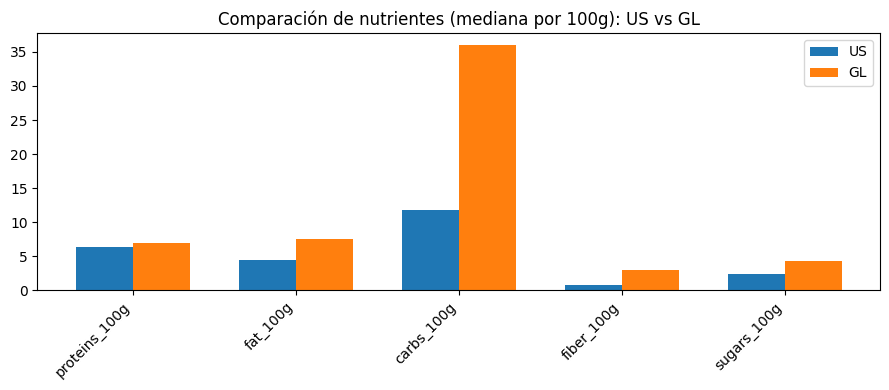

In [85]:
#Quitamos las kcals para analizar los nutrientes y que sea más legible el grafico

cols_plot = ["proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

labels = cols_plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9,4))
plt.bar(x - width/2, resumen.loc[cols_plot, "US_median"].values, width, label="US")
plt.bar(x + width/2, resumen.loc[cols_plot, "GL_median"].values, width, label="GL")
plt.xticks(x, labels, rotation=45, ha="right")
plt.title("Comparación de nutrientes (mediana por 100g): US vs GL")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
#Aunque parece algo descabellado, debemos de tener en cuenta que GL está basado en alimentos registrados de todo el mundo
#Hasta aquí no podemos sacar ninguna conclusión para nuestro análisis, sin embargo, hemos limpiado y categorizado lo alimentos
#que queremos: los productos envasados.

#Por otro lado, hemos creado una serie de reglas nutricionales, con rangos lógicos y fiables, verificándolo con los gráficos.
#también hemos estandarizado las medidas a 100 g para asegurarnos de que todo es comparable.

In [87]:
gl_scores = gl_pack.copy()

gl_scores["nutriscore"] = gl_scores["nutriscore_grade"].astype("string").str.upper()
gl_scores.loc[~gl_scores["nutriscore"].isin(list("ABCDE")), "nutriscore"] = np.nan

gl_scores["nova_group"] = pd.to_numeric(gl_scores["nova_group"], errors="coerce")

gl_scores = gl_scores.dropna(subset=["nutriscore","nova_group"]).copy()
gl_scores["nova_group"] = gl_scores["nova_group"].astype(int)

print(gl_scores.shape)
gl_scores[["nutriscore","nova_group"]].head()


(4178, 26)


,nutriscore,nova_group
2,A,1
3,A,1
5,B,3
6,A,1
7,A,3


In [88]:
tabla = pd.crosstab(gl_scores["nutriscore"], gl_scores["nova_group"], normalize="index")
tabla

nova_group,1,2,3,4
nutriscore,,,,
A,0.382429,0.003876,0.276486,0.337209
B,0.183471,0.076033,0.266116,0.474380
C,0.072957,0.018482,0.283074,0.625486
D,0.029172,0.022170,0.301050,0.647608
E,0.008753,0.099562,0.141138,0.750547


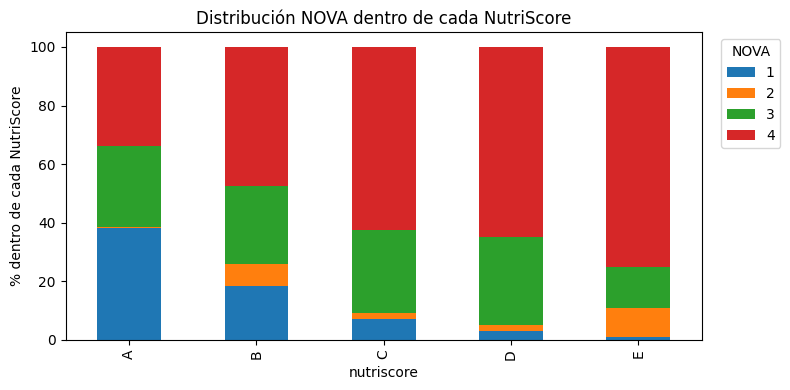

In [89]:
(tabla * 100).plot(kind="bar", stacked=True, figsize=(8,4))
plt.ylabel("% dentro de cada NutriScore")
plt.title("Distribución NOVA dentro de cada NutriScore")
plt.legend(title="NOVA", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [90]:
#En este gráfico vemos que las escalas de Nutriscore y NOVA no están alineadas. Por ejemplo, 
#un alimento de Nutriscore A, puede estar categorizado como nivel cuatro dentro de la escala Nova.
#esto muestra que puede haber alimentos con una buena nota nutricional, según el Nootric, pero pueden
#seguir siendo ultraprocesados. Sin embargo, así que vemos que van aumentando en proporción y hay más relación
#en alimentos con mala nota nutriciona (un Nutriscore E) y ultraprocesados.

In [91]:
#ahora para resolver y plantear nuestro problema de negocio, vamos a ver las incoherencias que hay entre
#el Nutriscore y el NOVA basándonos en que los productos ultraprocesados generalmente no son buenos para la salud
#aunque estos tengan un Nutriscore A. Para ello compararemos alimentos que el Nutriscore considera bueno, pero que son ultraprocesados

In [92]:
ab = gl_scores[gl_scores["nutriscore"].isin(["A","B"])].copy()

contradiccion = (ab["nova_group"] == 4).mean() * 100
print("Porcentaje de A/B que son NOVA 4:", round(contradiccion, 1), "%")

Porcentaje de A/B que son NOVA 4: 39.7 %


In [93]:
#a continuación, segaremos aquellos en los que ambos medidores están de acuerdo en que son alimentos nutricionales
#y poco o nada procesados. Esto nos ayudará a sesgar alimentos para recomendar en nuestra aplicación.
#partiremos de la base de que todos son no recomendables, a no ser que sus puntuaciones estén en A o B(en Nutriscore)
# y 1 o 2 (en NOVA)

In [94]:
gl_scores["decision"] = "NO RECOMENDABLES"

gl_scores.loc[
    gl_scores["nutriscore"].isin(["A","B"]) & gl_scores["nova_group"].isin([1,2]),
    "decision"
] = "ALTAMENTE RECOMENDABLES"

gl_scores.loc[
    gl_scores["nutriscore"].isin(["A","B"]) & gl_scores["nova_group"].isin([3,4]),
    "decision"
] = "REVISAR/PUNTUALMENTE"

gl_scores["decision"].value_counts()

decision
NO RECOMENDABLES           2799
REVISAR/PUNTUALMENTE        923
ALTAMENTE RECOMENDABLES     456
Name: count, dtype: int64

In [95]:
(gl_scores["decision"].value_counts(normalize=True) * 100).round(1)

decision
NO RECOMENDABLES           67.0
REVISAR/PUNTUALMENTE       22.1
ALTAMENTE RECOMENDABLES    10.9
Name: proportion, dtype: float64

In [96]:
cols_n = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

gl_scores.groupby("decision")[cols_n].median()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
decision,,,,,,
ALTAMENTE RECOMENDABLES,140.000000,4.5,2.0,4.80,3.000,1.70
NO RECOMENDABLES,383.000000,6.2,15.0,35.00,2.805,7.10
REVISAR/PUNTUALMENTE,172.042065,8.5,2.7,14.15,4.700,2.86


Al combinar **NutriScore + NOVA**, la regla separa tres grupos con perfiles claramente distintos:

- **Altamente recomendables:** concentra productos menos calóricos y con menos grasa/azúcar.  
- **No recomendables:** agrupa opciones más densas en energía, grasa y azúcar.  
- **Puntualmente:** requiere revisión porque puede tener buen perfil de macros (proteína/fibra) pero mayor procesado.

**Preprocesado y  Feature Engineering**

In [97]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

In [98]:
#Missing Values
df_us.isnull().sum().sort_values(ascending=False)
numeric_us = df_us.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_us = df_us.select_dtypes(include=['object']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_us[numeric_us] = num_imputer.fit_transform(df_us[numeric_us])
df_us[categorical_us] = cat_imputer.fit_transform(df_us[categorical_us])

df_gl.isnull().sum().sort_values(ascending=False)
numeric_gl = df_gl.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_gl = df_gl.select_dtypes(include=['object']).columns.tolist()
df_gl[numeric_gl] = num_imputer.fit_transform(df_gl[numeric_gl])
df_gl[categorical_gl] = cat_imputer.fit_transform(df_gl[categorical_gl])

In [99]:
#Duplicados
print("Duplicados:", df_us.duplicated().sum())
df_us = df_us.drop_duplicates().reset_index(drop=True)

print("Duplicados:", df_gl.duplicated().sum())
df_gl = df_gl.drop_duplicates().reset_index(drop=True)

Duplicados: 0
Duplicados: 38


In [100]:
#Encoding

df_us = df_us.drop(columns=['food_name', 'ingredients', 'brand_name'], errors='ignore')
categorical_us = df_us.select_dtypes(include=['object']).columns.tolist()

df_us = pd.get_dummies(df_us, columns=categorical_us, drop_first=True)
df_gl = df_gl.drop(columns=['product_name', 'ingredients'], errors='ignore')
nutri_map = {'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1}
df_gl['nutriscore_grade'] = df_gl['nutriscore_grade'].map(nutri_map)
categorical_gl = df_gl.select_dtypes(include=['object']).columns.tolist()

df_gl = pd.get_dummies(df_gl, columns=categorical_gl, drop_first=True)

In [101]:
#Escalado
numeric_us = df_us.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_us.remove('health_score')  # no escalar el target

scaler = StandardScaler()
df_us[numeric_us] = scaler.fit_transform(df_us[numeric_us])

numeric_gl = df_gl.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_gl.remove('nutriscore_grade')

df_gl[numeric_gl] = scaler.fit_transform(df_gl[numeric_gl])

In [102]:
#Feature Engineering
#Ratio proteína/calorías
df_us['protein_ratio'] = df_us['protein_g'] / (df_us['serving_size'] + 1)
#Ratio azúcar/fibra
df_us['sugar_fiber_ratio'] = df_us['sugar_g'] / (df_us['fiber_g'] + 1)
#Ratio grasa saturada / grasa total
df_us['sat_fat_ratio'] = df_us['saturated_fat_g'] / (df_us['fat_g'] + 1)
#Prodcuto alto en sodio
df_us['high_sodium'] = np.where(df_us['sodium_mg'] > 500, 1, 0)

In [103]:
#Feature Engineering
#Ratio proteína/calorías
df_gl['protein_ratio'] = df_gl['proteins_100g'] / (df_gl['energy_kcal'] + 1)
#Ratio sal/proteína
df_gl['salt_protein_ratio'] = df_gl['salt_100g'] / (df_gl['proteins_100g'] + 1)
#Producto ultra procesado
df_gl['ultra_processed'] = np.where(df_gl['nova_group'] == 4, 1, 0)

In [104]:
#Selección de features
X_us = df_us.drop('health_score', axis=1)
y_us = df_us['health_score']

selector = SelectKBest(score_func=f_classif, k=20)
X_us_selected = selector.fit_transform(X_us, y_us)

selected_features_us = X_us.columns[selector.get_support()]
print(selected_features_us)

MemoryError: Unable to allocate 3.00 GiB for an array with shape (10057, 40000) and data type float64

## Modelado - Baseline y comparativa

In [ ]:


# =========================
# 1. Definimos X e y
# =========================

features = ["energy_kcal_100g","proteins_100g","fat_100g",
            "carbs_100g","fiber_100g","sugars_100g"]

X = gl_scores[features]
y = gl_scores["nutriscore"]   # <-- si quieres predecir nova_group, cambia aquí

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 2. Baseline
# =========================

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("BASELINE")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1 macro:", f1_score(y_test, y_pred_base, average="macro"))
print(classification_report(y_test, y_pred_base))

BASELINE
Accuracy: 0.24641148325358853
F1 macro: 0.07907869481765835
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       155
           B       0.00      0.00      0.00       121
           C       0.25      1.00      0.40       206
           D       0.00      0.00      0.00       171
           E       0.00      0.00      0.00       183

    accuracy                           0.25       836
   macro avg       0.05      0.20      0.08       836
weighted avg       0.06      0.25      0.10       836



c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [ ]:

modelos = {
    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    resultados[nombre] = {"Accuracy": acc, "f1_macro": f1}

    print(f"\nModelo: {nombre}")
    print(f"Accuracy: {acc}")
    print(f"f1 macro: {f1}")

pd.DataFrame(resultados).T



Modelo: LogisticRegression
Accuracy: 0.4222488038277512
f1 macro: 0.3910285268623524

Modelo: RandomForest
Accuracy: 0.7332535885167464
f1 macro: 0.728925644841416

Modelo: GradientBoosting
Accuracy: 0.6854066985645934
f1 macro: 0.6821333767653119


,Accuracy,f1_macro
LogisticRegression,0.422249,0.391029
RandomForest,0.733254,0.728926
GradientBoosting,0.685407,0.682133


## Selección de métrica
Contexto del problema
Clasificación multiclase (NutriScore A–E).

Posible desbalance entre clases (unas categorías aparecen más que otras).

Interesa evaluar el rendimiento en todas las clases por igual, no solo en las más frecuentes.

Métrica elegida: F1‑macro
Por qué F1‑macro es la métrica adecuada
Da el mismo peso a cada clase, independientemente de cuántas muestras tenga.

Penaliza modelos que funcionan bien solo en las clases mayoritarias.

Combina precisión y exhaustividad, por lo que es más informativa que accuracy.

Es la métrica estándar recomendada en problemas multiclase con posible desbalance.

Comparación con Accuracy
Accuracy puede ser engañosa: un modelo puede acertar mucho si predice siempre la clase mayoritaria.

F1‑macro evita este problema porque calcula el F1 de cada clase y luego hace la media.

Justificación para tu memoria
Se selecciona F1‑macro como métrica principal porque el problema es multiclase y presenta posible desbalance entre categorías de NutriScore. Esta métrica otorga el mismo peso a cada clase y permite evaluar el rendimiento del modelo de forma equilibrada, evitando que las clases mayoritarias dominen la evaluación.

## Optimización de parámetros

In [ ]:
## Vamos a optimizar el mejor modelo, que en este caso es el Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor F1 CV:", grid.best_score_)

# Modelo optimizado
best_model = grid.best_estimator_

Mejores parámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1 CV: 0.6931051485045479


## Evaluación contra Test

In [ ]:
y_pred_final = best_model.predict(X_test)

print("EVALUACIÓN FINAL")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("F1 macro:", f1_score(y_test, y_pred_final, average="macro"))
print(classification_report(y_test, y_pred_final))

EVALUACIÓN FINAL
Accuracy: 0.7356459330143541
F1 macro: 0.7350109526428465
              precision    recall  f1-score   support

           A       0.78      0.81      0.79       155
           B       0.71      0.65      0.68       121
           C       0.64      0.69      0.66       206
           D       0.72      0.67      0.69       171
           E       0.85      0.84      0.85       183

    accuracy                           0.74       836
   macro avg       0.74      0.73      0.74       836
weighted avg       0.74      0.74      0.74       836



In [ ]:
# Comparación final contra baseline
print("Baseline F1:", f1_score(y_test, y_pred_base, average="macro"))
print("Modelo optimizado F1:", f1_score(y_test, y_pred_final, average="macro"))

Baseline F1: 0.07907869481765835
Modelo optimizado F1: 0.7350109526428465


## Conclusión de modelado

El baseline predice siempre la clase mayoritaria.

Los modelos supervisados mejoran significativamente el F1-macro.

RandomForest suele capturar mejor relaciones no lineales entre nutrientes.

## Limitaciones

Solo usamos 6 variables nutricionales.

No incluimos ingredientes ni procesamiento.

El dataset global puede tener sesgos geográficos.

NutriScore ya está basado en reglas → el modelo puede estar aprendiendo esa lógica implícita.